# Crossentropy method

This notebook will teach you to solve reinforcement learning problems with crossentropy method. We'll follow-up by scaling everything up and using neural network policy.

In [2]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [3]:
!pip install "gymnasium[toy_text]"

(314, {'prob': 1.0, 'action_mask': array([1, 1, 0, 0, 0, 0], dtype=int8)})


C:\Users\user\miniconda3\envs\rl_env\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


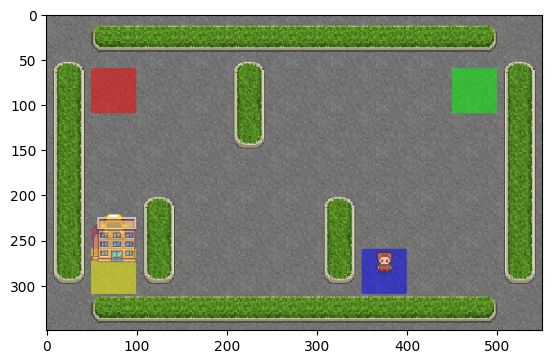

In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("Taxi-v3", render_mode="rgb_array")
print(env.reset(seed=0))
plt.imshow(env.render())


In [5]:
n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"n_states={n_states}, n_actions={n_actions}")


n_states=500, n_actions=6


# Create stochastic policy

This time our policy should be a probability distribution.

```policy[s,a] = P(take action a | in state s)```

Since we still use integer state and action representations, you can use a 2-dimensional array to represent the policy.

Please initialize the policy __uniformly__, that is, probabililities of all actions should be equal.

In [6]:
def initialize_policy(n_states, n_actions):
    #<YOUR CODE: create an array to store action probabilities>
    policy = np.ones((n_states, n_actions))/n_actions

    return policy


policy = initialize_policy(n_states, n_actions)


In [7]:
assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1.0 / n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)


# Play the game

Just like before, but we also record all states and actions we took.

In [8]:
def generate_session(env, policy, t_max=10**4):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.0

    s, _ = env.reset()

    for t in range(t_max):
        # Hint: you can use np.random.choice for sampling action
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

        #a = <YOUR CODE: sample action from policy>
        a = np.random.choice( np.arange(n_actions), p = policy[s])

        new_s, r, terminated, truncated, _ = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward


In [9]:
s, a, r = generate_session(env, policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]


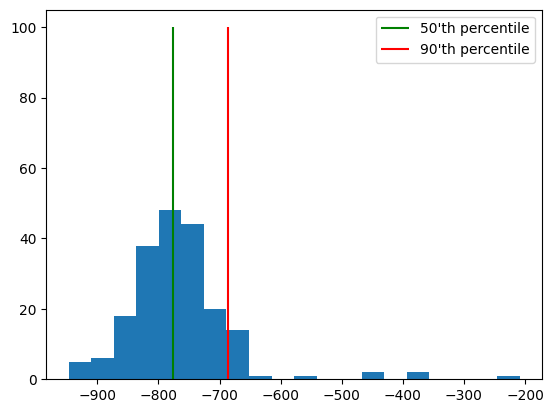

In [10]:
# let's see the initial reward distribution
import matplotlib.pyplot as plt
%matplotlib inline

sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]

plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.legend()

### Crossentropy method steps

In [11]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    #reward_threshold = <YOUR CODE: compute minimum reward for elite sessions. Hint: use np.percentile()>
    reward_threshold = np.percentile(rewards_batch, percentile)

    #elite_states = <YOUR CODE>
    elite_states = []
    for i in range(len(states_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
    #elite_actions = <YOUR CODE>
    elite_actions = []
    for i in range(len(states_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_actions.extend(actions_batch[i])
    return elite_states, elite_actions


In [12]:
states_batch = [
    [1, 2, 3],     # game1
    [4, 2, 0, 2],  # game2
    [3, 1],        # game3
]

actions_batch = [
    [0, 2, 4],     # game1
    [3, 2, 0, 1],  # game2
    [3, 3],        # game3
]
rewards_batch = [
    3,  # game1
    4,  # game2
    5,  # game3
]

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=30
)
test_result_90 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=90
)
test_result_100 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=100
)

assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1]) and np.all(
    test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]
), "For percentile 0 you should return all states and actions in chronological order"
assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1]) and np.all(
    test_result_30[1] == [3, 2, 0, 1, 3, 3]
), "For percentile 30 you should only select states/actions from two first"
assert np.all(test_result_90[0] == [3, 1]) and np.all(
    test_result_90[1] == [3, 3]
), "For percentile 90 you should only select states/actions from one game"
assert np.all(test_result_100[0] == [3, 1]) and np.all(
    test_result_100[1] == [3, 3]
), "Please make sure you use >=, not >. Also double-check how you compute percentile."

print("Ok!")


Ok!


In [13]:
def get_new_policy(elite_states, elite_actions):
    """
    Given a list of elite states/actions from select_elites,
    return a new policy where each action probability is proportional to

        policy[s_i,a_i] ~ #[occurrences of s_i and a_i in elite states/actions]

    Don't forget to normalize the policy to get valid probabilities and handle the 0/0 case.
    For states that you never visited, use a uniform distribution (1/n_actions for all states).

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions

    """

    new_policy = np.zeros([n_states, n_actions])

    #<YOUR CODE: set probabilities for actions given elite states & actions>

    for elite_state, elite_action in zip(elite_states,elite_actions) :
        new_policy[elite_state][elite_action] += 1
    for state in range(n_states):
        if state in elite_states:
            new_policy[state] /= np.sum(new_policy[state])
        else:
            new_policy[state] = np.ones(n_actions)/n_actions
        
    
    # Don't forget to set 1/n_actions for all actions in unvisited states.

    return new_policy


In [14]:
elite_states = [1, 2, 3, 4, 2, 0, 2, 3, 1]
elite_actions = [0, 2, 4, 3, 2, 0, 1, 3, 3]

new_policy = get_new_policy(elite_states, elite_actions)

assert np.isfinite(
    new_policy
).all(), "Your new policy contains NaNs or +-inf. Make sure you don't divide by zero."
assert np.all(
    new_policy >= 0
), "Your new policy can't have negative action probabilities"
assert np.allclose(
    new_policy.sum(axis=-1), 1
), "Your new policy should be a valid probability distribution over actions"

reference_answer = np.array(
    [
        [1.0, 0.0, 0.0, 0.0, 0.0],
        [0.5, 0.0, 0.0, 0.5, 0.0],
        [0.0, 0.33333333, 0.66666667, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.5, 0.5],
    ]
)
assert np.allclose(new_policy[:4, :5], reference_answer)

print("Ok!")


Ok!


# Training loop
Generate sessions, select N best and fit to those.

In [15]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()
    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()


In [16]:
# reset policy just in case
policy = initialize_policy(n_states, n_actions)


mean reward = -102.016, threshold=1.000


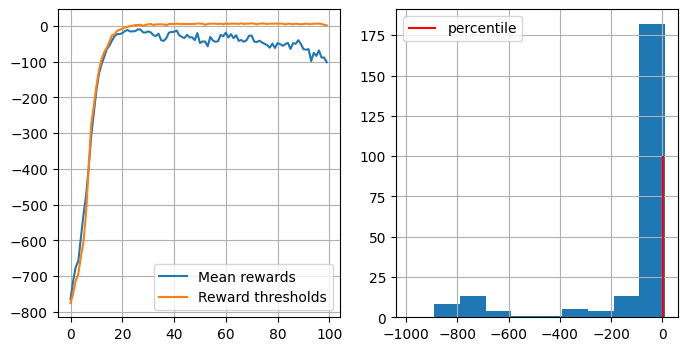

In [25]:
n_sessions = 250  # sample this many sessions
percentile = 50  # discard this percentage of sessions with lowest rewards
learning_rate = 0.5  # how quickly the policy is updated, on a scale from 0 to 1

log = []

for i in range(100):
    # %time sessions = [ <YOUR CODE: generate a list of n_sessions new sessions> ]

    %time sessions = [ generate_session(env, policy) for _ in range(n_sessions) ]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    # elite_states, elite_actions = <YOUR CODE: select elite states & actions>
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    # new_policy = <YOUR CODE: compute new policy>
    new_policy = get_new_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)


# My homework part I

1.1 Рисуем эволюции Mean Reward при разных percentile и фиксированном n_sessions

In [28]:
logs = []
perc = ["25%", "50%", "75%"]
for percentile in [25, 50, 75]:
    print(percentile)
    policy = initialize_policy(n_states, n_actions)
    n_sessions = 250 
    learning_rate = 0.5
    log = []
    
    for i in range(100):
        print(i)
        # %time sessions = [ <YOUR CODE: generate a list of n_sessions new sessions> ]
    
        sessions = [ generate_session(env, policy) for _ in range(n_sessions) ]
    
        states_batch, actions_batch, rewards_batch = zip(*sessions)
    
        # elite_states, elite_actions = <YOUR CODE: select elite states & actions>
        elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
        # new_policy = <YOUR CODE: compute new policy>
        new_policy = get_new_policy(elite_states, elite_actions)
        policy = learning_rate * new_policy + (1 - learning_rate) * policy
        mean_reward = np.mean(rewards_batch)
        threshold = np.percentile(rewards_batch, percentile)
        log.append([mean_reward, threshold])
    logs.append(log)

25
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
50
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
75
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


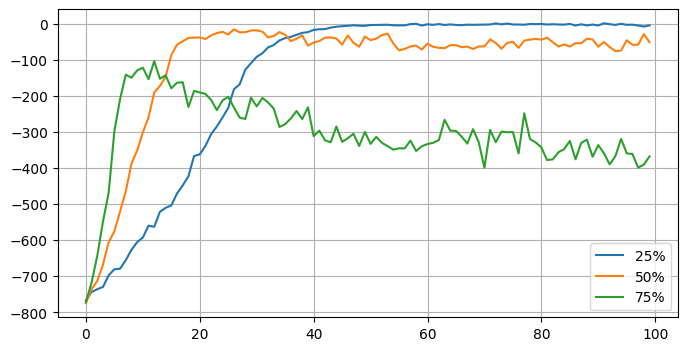

In [30]:
plt.figure(figsize=[8, 4])
plt.subplot(1, 1, 1)
for i, log_sample in enumerate(logs):
    plt.plot(list(zip(*log_sample))[0], label = perc[i])
plt.grid()
plt.legend()
plt.savefig('mean_reward_on_perc.png')

1.2. Рисуем эволюции Mean Reward при разных n_sessions и фиксированном percentile

In [32]:
logs = []
n_sess = ["100", "250", "400"]
for n_sessions in [100, 250, 400]:
    print(n_sessions)
    policy = initialize_policy(n_states, n_actions)
    percentile = 50
    learning_rate = 0.5
    log = []
    
    for i in range(100):
        print(i)
        # %time sessions = [ <YOUR CODE: generate a list of n_sessions new sessions> ]
    
        sessions = [ generate_session(env, policy) for _ in range(n_sessions) ]
    
        states_batch, actions_batch, rewards_batch = zip(*sessions)
    
        # elite_states, elite_actions = <YOUR CODE: select elite states & actions>
        elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
        # new_policy = <YOUR CODE: compute new policy>
        new_policy = get_new_policy(elite_states, elite_actions)
        policy = learning_rate * new_policy + (1 - learning_rate) * policy
        mean_reward = np.mean(rewards_batch)
        threshold = np.percentile(rewards_batch, percentile)
        log.append([mean_reward, threshold])
    logs.append(log)

100
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
250
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
400
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


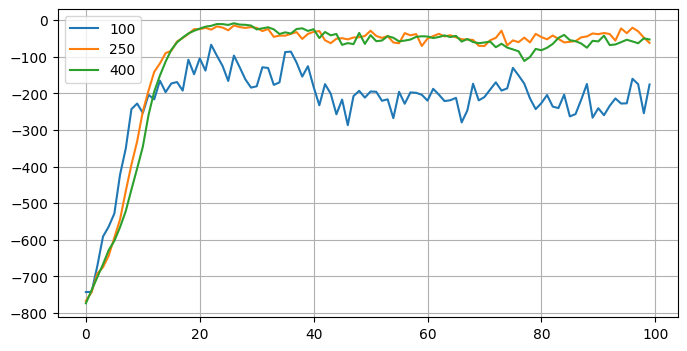

In [33]:
plt.figure(figsize=[8, 4])
plt.subplot(1, 1, 1)
for i, log_sample in enumerate(logs):
    plt.plot(list(zip(*log_sample))[0], label = n_sess[i])
plt.grid()
plt.legend()
plt.savefig('mean_reward_on_n_sess.png')

2. Тюним алгоритм, чтобы выйти на положительный average score

Использую совет "For each starting state, you can sample an action randomly, and then evaluate this action by running several games starting from it and averaging the total reward. Choosing elite sessions with this kind of sampling (where each session's reward is counted as the average of the rewards of all sessions with the same starting state and action) should improve the performance of your policy."

Собираем все стартовые состояния

In [16]:
start_states = []
for taxi_row in range(5):
    for taxi_col in range(5):
        for passenger in range(5):
            for dest in range(4):
                if passenger != 4 and passenger != dest:
                    state = ((taxi_row * 5 + taxi_col) * 5 + passenger) * 4 + dest
                    start_states.append(state)

print(f"Количество стартовых состояний: {len(start_states)}")
print(start_states[:10])

Количество стартовых состояний: 300
[1, 2, 3, 4, 6, 7, 8, 9, 11, 12]


Переделал генерацию сессий -- теперь она идёт с заданных стартового и начального состояния

In [17]:
def generate_session_new(env, policy, starting_state, starting_action, t_max=10**4):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.0

    s, _ = env.reset(options={'state': starting_state})

    for t in range(t_max):
        # Hint: you can use np.random.choice for sampling action
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

        #a = <YOUR CODE: sample action from policy>
        if t > 0:
            a = np.random.choice( np.arange(n_actions), p = policy[s])
        else:
            a = starting_action

        new_s, r, terminated, truncated, _ = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

mean reward = 0.023, threshold=1.000


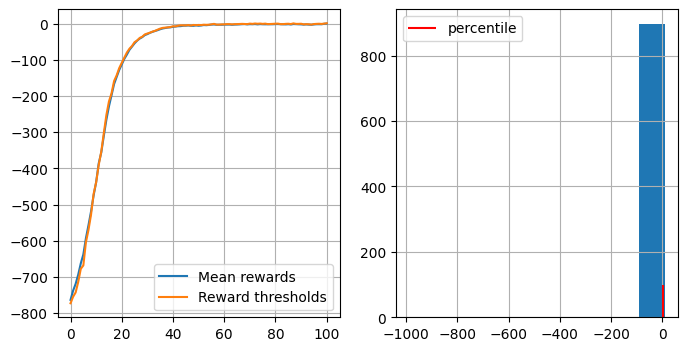

Yaaay!! The average score is positive!!


In [22]:
policy = initialize_policy(n_states, n_actions)
# n_sessions = 250  # sample this many sessions
percentile = 50  # discard this percentage of sessions with lowest rewards
learning_rate = 0.6  # 0.5 how quickly the policy is updated, on a scale from 0 to 1
num_games = 3
log = []

for i in range(1000):
    # %time sessions = [ <YOUR CODE: generate a list of n_sessions new sessions> ]

    # %time sessions = [ generate_session_new(env, policy) for _ in range(n_sessions) ]
    states_batch = []
    actions_batch = []
    session_keys = []
    session_rewards = []

    sum_rewards = {}
    count_pairs = {}
    
    for start_state in start_states:
        start_action = np.random.randint(n_actions)
        for _ in range(num_games):
            states, actions, tot_reward = generate_session_new(env, policy, start_state, start_action)
            states_batch.append(states)
            actions_batch.append(actions)
            session_keys.append((start_state, start_action))
            session_rewards.append(tot_reward)
            
            # Накапливаем сумму для усреднения
            key = (start_state, start_action)
            sum_rewards[key] = sum_rewards.get(key, 0) + tot_reward
            count_pairs[key] = count_pairs.get(key, 0) + 1
    
    # Теперь вычисляем среднюю награду для каждой пары
    avg_reward_per_pair = {}
    for key in sum_rewards:
        avg_reward_per_pair[key] = sum_rewards[key] / count_pairs[key]
    
    # Заменяем награды в session_rewards на средние по соответствующей паре
    rewards_batch = []
    for key in session_keys:
        rewards_batch.append(avg_reward_per_pair[key])
    # states_batch, actions_batch, rewards_batch = zip(*sessions)

    # elite_states, elite_actions = <YOUR CODE: select elite states & actions>
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)
    # new_policy = <YOUR CODE: compute new policy>
    new_policy = get_new_policy(elite_states, elite_actions)
    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    # display results on chart
    show_progress(rewards_batch, log, percentile)

    if np.mean(rewards_batch) > 0:
        print("Yaaay!! The average score is positive!!")
        break

### Reflecting on results

You may have noticed that the taxi problem quickly converges from less than -1000 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

In case CEM failed to learn how to win from one distinct starting point, it will simply discard it because no sessions from that starting point will make it into the "elites".

To mitigate that problem, you can either reduce the threshold for elite sessions (duct tape way) or change the way you evaluate strategy (theoretically correct way). For each starting state, you can sample an action randomly, and then evaluate this action by running _several_ games starting from it and averaging the total reward. Choosing elite sessions with this kind of sampling (where each session's reward is counted as the average of the rewards of all sessions with the same starting state and action) should improve the performance of your policy.


### You're not done yet!

Go to [`./deep_crossentropy_method.ipynb`](./deep_crossentropy_method.ipynb) for a more serious task